# Basic electrophysiology analysis with MNE

[Google Colab Link](https://colab.research.google.com/drive/1HdppyNS3r9p-A772OgnGGKB5HO1WzDAk?usp=sharing)

This notebook provides a compact teaching example for reading BrainVision electrophysiology data, extracting events, epoching one auxiliary channel, computing PSD-derived features, and visualizing time–frequency activity with wavelets.

The same workflow can be applied to `Aux1` and `Aux2`, for example if each channel contains data from a different participant.

## 1. Imports and configuration

In [13]:
from pathlib import Path

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import seaborn as sns

from scipy.ndimage import gaussian_filter1d

# Path to the BrainVision header file.
# The .vhdr file points to the .eeg and .vmrk files.
eeg_path = Path(
    "/Users/isaant/Documents/PosDoc/Workshops/INN_summer_research_bootcamp_2026/EEG_data/Pilot.vhdr"
)

# Channels to analyze. Aux2 can be used for a second participant.
channels_of_interest = ["Aux1", "Aux2"]

# Events to use: first, third, and fifth event.
selected_idx = [0, 2, 4]

# Epoch window in seconds after each event.
tmin = 0
tmax = 10

# Filtering and spectral parameters.
l_freq = 5
h_freq = 200
notch_freqs = [60, 120, 180]  # Example: [60, 120, 180]
psd_window_sec = 5
psd_overlap_sec = 2.5
fmax = 200
smooth_sigma = 5

## 2. Helper functions

In [14]:
def load_brainvision(vhdr_path):
    """Load BrainVision data and print basic metadata."""
    raw = mne.io.read_raw_brainvision(vhdr_path, preload=True)
    print(raw)
    print(raw.info)
    print(raw.ch_names)
    print(f"Sampling frequency: {raw.info['sfreq']} Hz")
    return raw


def preprocess_raw(raw, l_freq=5, h_freq=200, notch_freqs=None):
    """Apply a simple band-pass filter and optional notch filter."""
    raw_filt = raw.copy()
    raw_filt.filter(l_freq, h_freq)
    if notch_freqs is not None:
        raw_filt.notch_filter(notch_freqs)
    return raw_filt


def extract_events_from_annotations(raw):
    """Extract MNE events from BrainVision annotations."""
    print(raw.annotations)
    for ann in raw.annotations:
        print(ann)

    events, event_id = mne.events_from_annotations(raw)
    events_in_seconds = events[:, 0].astype(float) / raw.info["sfreq"]

    print("Event ID mapping:", event_id)
    print("Event times in seconds:", events_in_seconds)
    print(f"Number of events: {len(events)}")

    return events, event_id, events_in_seconds


def make_epochs(raw, events, selected_idx, tmin=0, tmax=10, picks=None):
    """Create epochs after selected events."""
    if len(events) <= max(selected_idx):
        raise ValueError(
            f"Need at least {max(selected_idx) + 1} events, but only found {len(events)}."
        )

    selected_events = events[selected_idx, :]

    epochs = mne.Epochs(
        raw,
        events=selected_events,
        event_id=None,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        picks=picks,
        preload=True,
    )

    print(epochs)
    return epochs, selected_events


def compute_channel_psd(epochs, channel, fmax=200, window_sec=5, overlap_sec=2.5):
    """Compute Welch PSD for one channel across epochs."""
    sfreq = epochs.info["sfreq"]
    epochs_ch = epochs.copy().pick([channel])

    psd = epochs_ch.compute_psd(
        fmax=fmax,
        method="welch",
        n_fft=int(window_sec * sfreq),
        n_overlap=int(overlap_sec * sfreq),
        average="mean",
        window="hann",
    )

    psds, psd_freqs = psd.get_data(return_freqs=True)
    return psd, psds, psd_freqs


def plot_psd_per_epoch(psds, psd_freqs, selected_idx, channel, smooth_sigma=5):
    """Plot raw and smoothed PSD for each selected epoch."""
    plt.figure(figsize=(10, 5))

    for i in range(psds.shape[0]):
        p = psds[i, 0, :]
        p_smooth = gaussian_filter1d(p, sigma=smooth_sigma)
        plt.plot(psd_freqs, p, alpha=0.45, label=f"Event {selected_idx[i] + 1}")
        plt.plot(psd_freqs, p_smooth, linewidth=2)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title(f"{channel} PSD per epoch")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def compute_psd_features(psds, psd_freqs, selected_idx, smooth_sigma=5):
    """Extract peak frequency, peak power, total power, mean frequency, and median frequency."""
    results = []

    for i in range(psds.shape[0]):
        p = psds[i, 0, :]
        p = gaussian_filter1d(p, sigma=smooth_sigma)

        peak_idx = np.argmax(p)
        peak_freq = psd_freqs[peak_idx]
        peak_power = p[peak_idx]
        total_power = np.trapezoid(p, psd_freqs)
        mean_freq = np.sum(psd_freqs * p) / np.sum(p)

        cumsum = np.cumsum(p)
        cumsum = cumsum / cumsum[-1]
        median_freq = psd_freqs[np.where(cumsum >= 0.5)[0][0]]

        results.append({
            "trial": f"Event {selected_idx[i] + 1}",
            "peak_freq": peak_freq,
            "peak_power": peak_power,
            "total_power": total_power,
            "mean_freq": mean_freq,
            "median_freq": median_freq,
        })

    return pd.DataFrame(results)


def plot_wavelet_spectrogram(raw, channel, events_in_seconds=None, selected_idx=None,
                             freq_min=5, freq_max=200, freq_step=1,
                             wavelet="cmor1.5-1.0", cmap="jet"):
    """Compute and plot a continuous wavelet transform for one channel."""
    aux = raw.copy().pick([channel])
    x = aux.get_data()[0]
    sfreq = raw.info["sfreq"]

    x = x - np.mean(x)

    wavelet_freqs_requested = np.arange(freq_min, freq_max + 1, freq_step)
    scales = pywt.central_frequency(wavelet) * sfreq / wavelet_freqs_requested

    coef, wavelet_freqs = pywt.cwt(
        x,
        scales,
        wavelet,
        sampling_period=1 / sfreq,
    )

    power = np.abs(coef) ** 2
    power_db = 10 * np.log10(power + np.finfo(float).eps)
    times = np.arange(len(x)) / sfreq

    plt.figure(figsize=(14, 5))
    plt.pcolormesh(times, wavelet_freqs, power_db, shading="auto", cmap=cmap)

    if events_in_seconds is not None:
        marker_times = events_in_seconds if selected_idx is None else events_in_seconds[selected_idx]
        for t in marker_times:
            plt.axvline(t, linestyle="--", linewidth=3, color="k")

    plt.colorbar(label="Power (dB)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"{channel} Wavelet Spectrogram")
    plt.ylim(freq_min, freq_max)
    plt.tight_layout()
    plt.show()

    return power_db, times, wavelet_freqs


def analyze_channel(raw, events, events_in_seconds, channel, selected_idx, tmin=0, tmax=10):
    """Run the complete teaching analysis for one auxiliary channel."""
    print(f"===== Analyzing {channel} =====")

    epochs, selected_events = make_epochs(
        raw,
        events=events,
        selected_idx=selected_idx,
        tmin=tmin,
        tmax=tmax,
        picks=[channel],
    )

    psd, psds, psd_freqs = compute_channel_psd(
        epochs,
        channel=channel,
        fmax=fmax,
        window_sec=psd_window_sec,
        overlap_sec=psd_overlap_sec,
    )

    plot_psd_per_epoch(psds, psd_freqs, selected_idx, channel, smooth_sigma=smooth_sigma)

    features = compute_psd_features(psds, psd_freqs, selected_idx, smooth_sigma=smooth_sigma)
    print(features)

    plot_wavelet_spectrogram(
        raw,
        channel=channel,
        events_in_seconds=events_in_seconds,
        selected_idx=selected_idx,
        freq_min=5,
        freq_max=200,
        freq_step=1,
        cmap="jet",
    )

    return {
        "epochs": epochs,
        "selected_events": selected_events,
        "psd": psd,
        "psds": psds,
        "psd_freqs": psd_freqs,
        "features": features,
    }

## 3. Load and inspect the data

In [15]:
raw = load_brainvision(eeg_path)

Extracting parameters from /Users/isaant/Documents/PosDoc/Workshops/INN_summer_research_bootcamp_2026/EEG_data/Pilot.vhdr...
Setting channel info structure...
Reading 0 ... 43829  =      0.000 ...    87.658 secs...
<RawBrainVision | Pilot.eeg, 5 x 43830 (87.7 s), ~1.7 MiB, data loaded>
<Info | 7 non-empty values
 bads: []
 ch_names: Aux1, Aux2, x_dir, y_dir, z_dir
 chs: 2 EEG, 3 misc
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 131.0 Hz
 meas_date: 2026-04-23 11:08:44 UTC
 nchan: 5
 projs: []
 sfreq: 500.0 Hz
>
['Aux1', 'Aux2', 'x_dir', 'y_dir', 'z_dir']
Sampling frequency: 500.0 Hz


/var/folders/n3/75k7s33n5x90gswnk6ytkgvr0000gn/T/ipykernel_5689/754324271.py:3: RuntimeWarning: Channels contain different lowpass filters. Highest (weakest) filter setting (131.00 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(vhdr_path, preload=True)


## 4. Preprocess and inspect the raw signal

In [16]:
raw_filt = preprocess_raw(
    raw,
    l_freq=l_freq,
    h_freq=h_freq,
    notch_freqs=notch_freqs,
)

raw_filt.plot()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 5 - 2e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 5.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Upper passband edge: 200.00 Hz
- Upper transition bandwidth: 50.00 Hz (-6 dB cutoff frequency: 225.00 Hz)
- Filter length: 825 samples (1.650 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3301 samples (6.602 s)



## 5. Extract events from BrainVision annotations

In [17]:
events, event_id, events_in_seconds = extract_events_from_annotations(raw_filt)

<Annotations | 6 segments: Stimulus/S 14 (3), Stimulus/S 15 (3)>
OrderedDict({'onset': np.float64(7.938), 'duration': np.float64(0.002), 'description': np.str_('Stimulus/S 14'), 'orig_time': datetime.datetime(2026, 4, 23, 11, 8, 44, 546352, tzinfo=datetime.timezone.utc), 'extras': {}})
OrderedDict({'onset': np.float64(8.122), 'duration': np.float64(0.002), 'description': np.str_('Stimulus/S 15'), 'orig_time': datetime.datetime(2026, 4, 23, 11, 8, 44, 546352, tzinfo=datetime.timezone.utc), 'extras': {}})
OrderedDict({'onset': np.float64(50.362), 'duration': np.float64(0.002), 'description': np.str_('Stimulus/S 14'), 'orig_time': datetime.datetime(2026, 4, 23, 11, 8, 44, 546352, tzinfo=datetime.timezone.utc), 'extras': {}})
OrderedDict({'onset': np.float64(50.52), 'duration': np.float64(0.002), 'description': np.str_('Stimulus/S 15'), 'orig_time': datetime.datetime(2026, 4, 23, 11, 8, 44, 546352, tzinfo=datetime.timezone.utc), 'extras': {}})
OrderedDict({'onset': np.float64(72.214), 'dur

## 6. Quick PSD of the full raw recording for one channel

Effective window size : 5.000 (s)
Plotting amplitude spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/n3/75k7s33n5x90gswnk6ytkgvr0000gn/T/ipykernel_5689/597076180.py:9: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  ).plot(


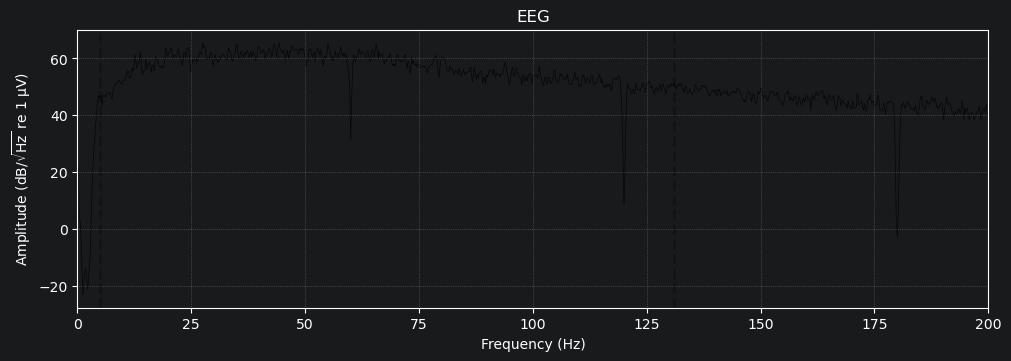

In [18]:
raw_filt.compute_psd(
    fmax=fmax,
    method="welch",
    picks=["Aux1"],
    n_fft=int(5 * raw_filt.info["sfreq"]),
    n_overlap=int(2.5 * raw_filt.info["sfreq"]),
    average="mean",
    window="hann",
).plot(
    picks="data",
    exclude="bads",
    amplitude=True,
    show=False,
)

## 7. Analyze Aux1

This example treats `Aux1` as the first participant or first channel of interest.

===== Analyzing Aux1 =====
Not setting metadata
3 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 3 events and 5001 original time points ...
0 bad epochs dropped
<Epochs | 3 events (all good), 0 – 10 s (baseline off), ~123 KiB, data loaded,
 '14': 3>
Effective window size : 5.000 (s)


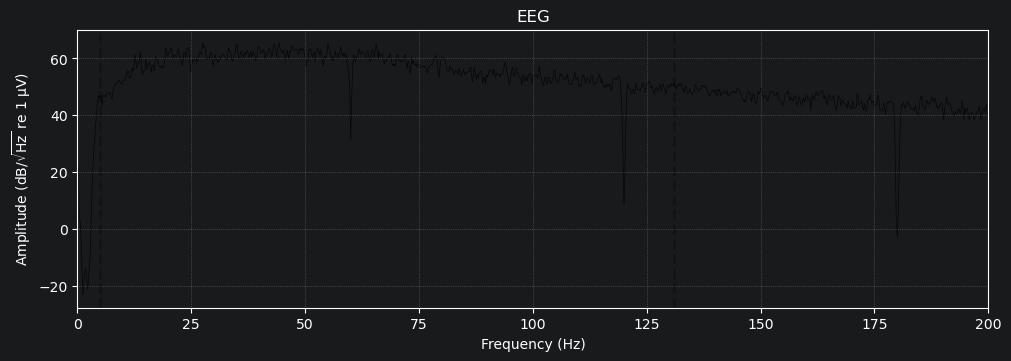

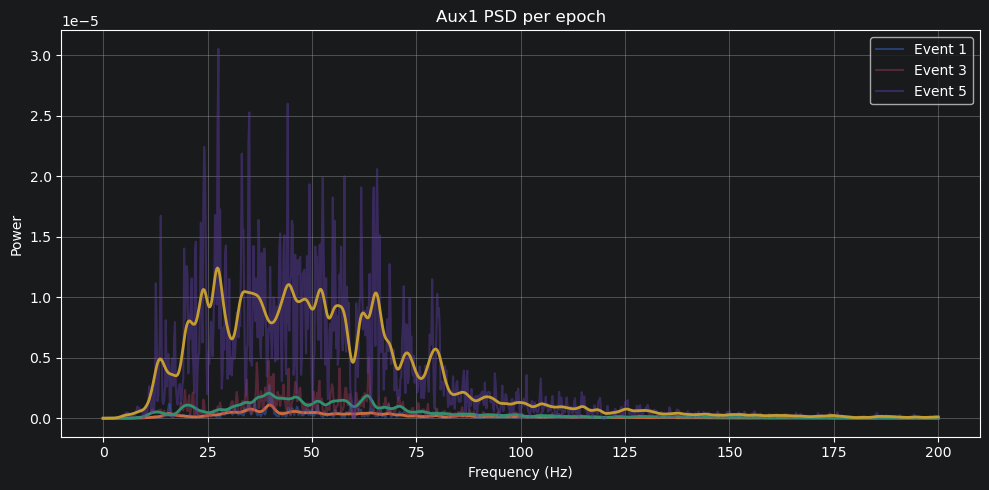

     trial  peak_freq  peak_power  total_power  mean_freq  median_freq
0  Event 1       39.8    0.000001     0.000033  59.812378         50.8
1  Event 3       39.6    0.000002     0.000087  58.060695         51.2
2  Event 5       27.4    0.000012     0.000610  52.740552         48.0


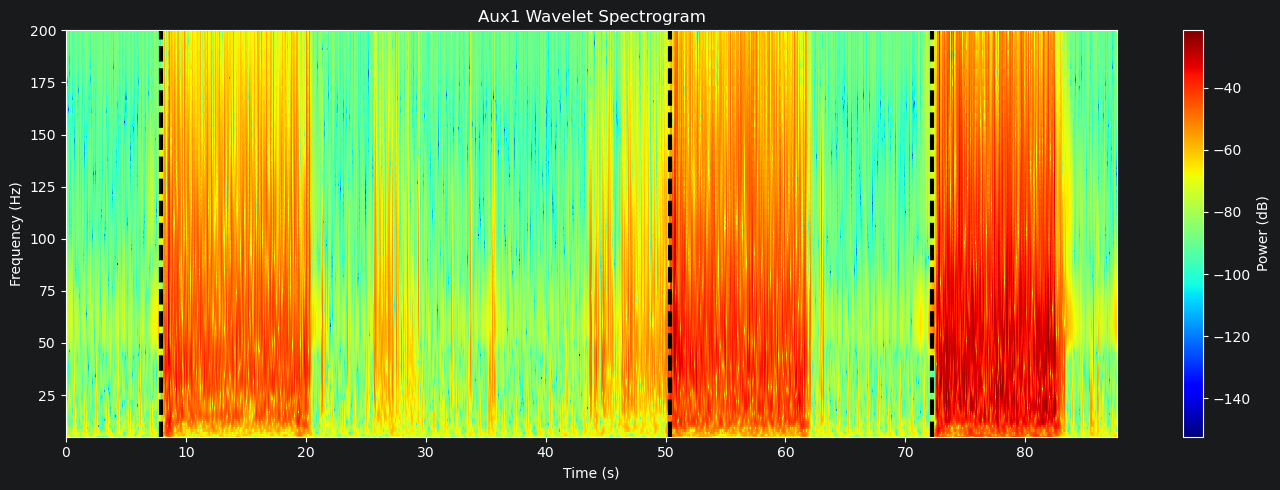

,trial,peak_freq,peak_power,total_power,mean_freq,median_freq
0,Event 1,39.8,0.000001,0.000033,59.812378,50.8
1,Event 3,39.6,0.000002,0.000087,58.060695,51.2
2,Event 5,27.4,0.000012,0.000610,52.740552,48.0


Channels marked as bad:
none


In [19]:
results_aux1 = analyze_channel(
    raw_filt,
    events=events,
    events_in_seconds=events_in_seconds,
    channel="Aux1",
    selected_idx=selected_idx,
    tmin=tmin,
    tmax=tmax,
)

results_aux1["features"]

## 8. Analyze Aux2

Run this cell when `Aux2` contains data from another participant.

===== Analyzing Aux2 =====
Not setting metadata
3 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 3 events and 5001 original time points ...
0 bad epochs dropped
<Epochs | 3 events (all good), 0 – 10 s (baseline off), ~123 KiB, data loaded,
 '14': 3>
Effective window size : 5.000 (s)


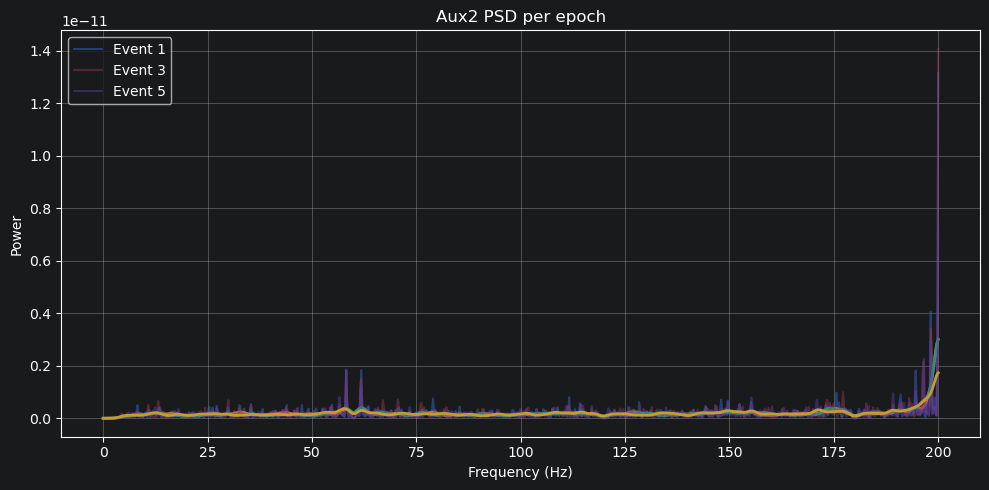

     trial  peak_freq    peak_power   total_power   mean_freq  median_freq
0  Event 1      200.0  2.990740e-12  3.964771e-11  118.609423        124.8
1  Event 3      200.0  3.013809e-12  3.858758e-11  123.421336        131.0
2  Event 5      200.0  1.730918e-12  3.816129e-11  118.568139        123.8


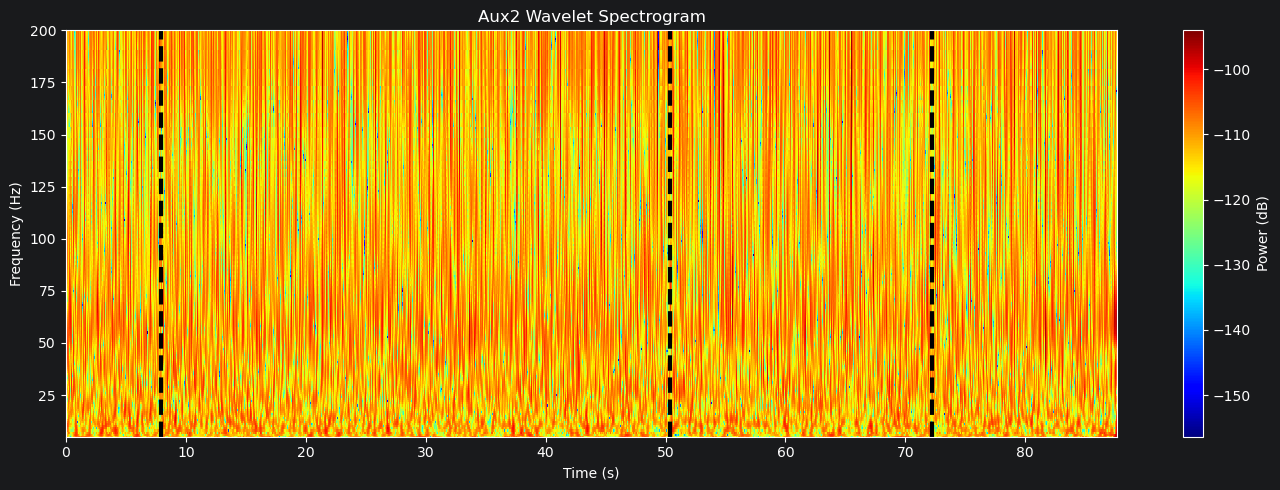

,trial,peak_freq,peak_power,total_power,mean_freq,median_freq
0,Event 1,200.0,2.990740e-12,3.964771e-11,118.609423,124.8
1,Event 3,200.0,3.013809e-12,3.858758e-11,123.421336,131.0
2,Event 5,200.0,1.730918e-12,3.816129e-11,118.568139,123.8


In [20]:
results_aux2 = analyze_channel(
    raw_filt,
    events=events,
    events_in_seconds=events_in_seconds,
    channel="Aux2",
    selected_idx=selected_idx,
    tmin=tmin,
    tmax=tmax,
)

results_aux2["features"]

## 9. Combined table for both channels / participants

In [21]:
df_aux1 = results_aux1["features"].copy()
df_aux1.insert(0, "channel", "Aux1")

df_aux2 = results_aux2["features"].copy()
df_aux2.insert(0, "channel", "Aux2")

features_all = pd.concat([df_aux1, df_aux2], ignore_index=True)
features_all['weight'] = [1,2,3,1,2,3] ## CHANGE THIS!! 
print(features_all)

  channel    trial  peak_freq    peak_power   total_power   mean_freq  \
0    Aux1  Event 1       39.8  1.096496e-06  3.332089e-05   59.812378   
1    Aux1  Event 3       39.6  2.065256e-06  8.703310e-05   58.060695   
2    Aux1  Event 5       27.4  1.242139e-05  6.101246e-04   52.740552   
3    Aux2  Event 1      200.0  2.990740e-12  3.964771e-11  118.609423   
4    Aux2  Event 3      200.0  3.013809e-12  3.858758e-11  123.421336   
5    Aux2  Event 5      200.0  1.730918e-12  3.816129e-11  118.568139   

   median_freq  weight  
0         50.8       1  
1         51.2       2  
2         48.0       3  
3        124.8       1  
4        131.0       2  
5        123.8       3  


## 10. Optional: save feature table

In [22]:
output_csv = eeg_path.with_name("emg_psd_features.csv")
features_all.to_csv(output_csv, index=False)
print(f"Saved: {output_csv}")

Saved: /Users/isaant/Documents/PosDoc/Workshops/INN_summer_research_bootcamp_2026/EEG_data/emg_psd_features.csv


## 11. Visualizing Results! 

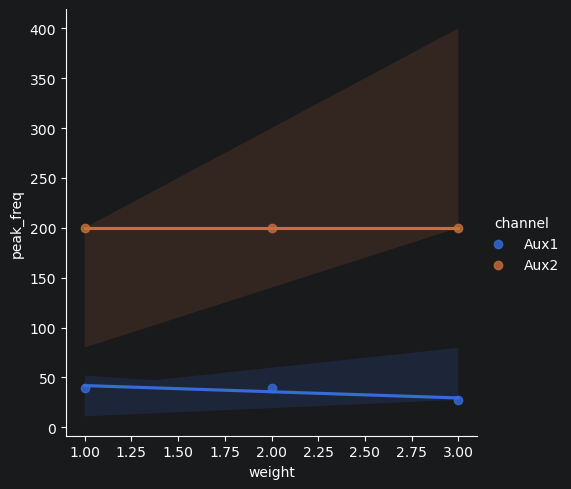

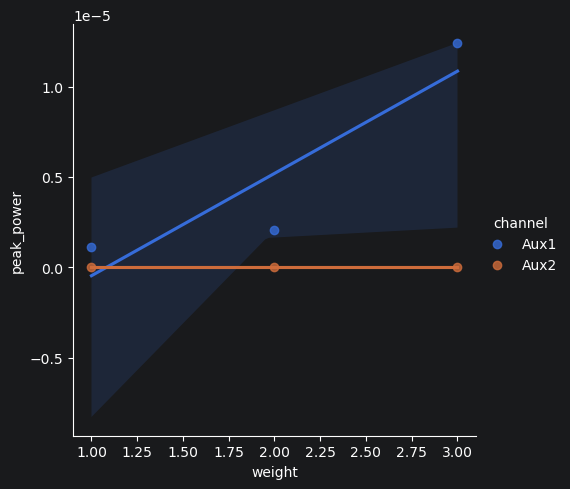

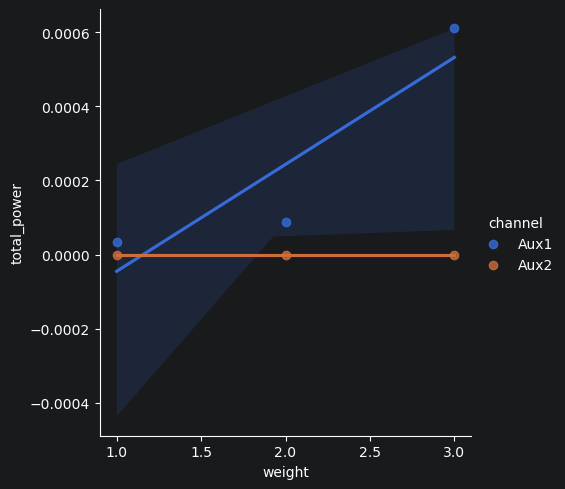

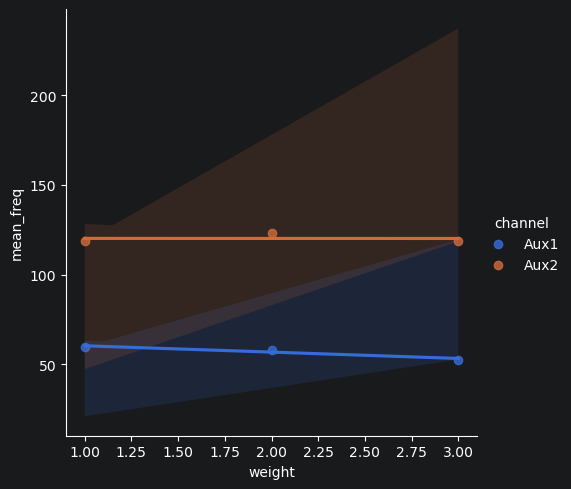

In [23]:
sns.lmplot(data = features_all, x='weight' ,y='peak_freq', hue="channel")
plt.show()
sns.lmplot(data = features_all, x='weight' ,y='peak_power', hue="channel")
plt.show()
sns.lmplot(data = features_all, x='weight' ,y='total_power', hue="channel")
plt.show()
sns.lmplot(data = features_all, x='weight' ,y='mean_freq', hue="channel")
plt.show()

